# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
working_dir = os.getcwd()
FOLDER_NAME = os.path.basename(working_dir)
FILE_NAME = 'macd_xlstm'

STOCK = 'BTC'
FREQ = '1h'

TRADE_PRICE = 'close'


SEQ_LENGTH = 120
BATCH_SIZE = 16

TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [3]:
os.chdir(os.path.join('..','data'))
df = pd.read_csv('BTCUSD_2023_2024.csv', index_col='Gmt time')
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S.%f", errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [4]:
os.chdir('..')
from utils.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

In [5]:
close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 close prices.


In [6]:
train = close[:int(np.floor(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')


train size:3240, val size:405, test size:405.


In [8]:
os.chdir('denoise')
from dwt import *
os.chdir(os.path.join('..', 'macdxlstm'))

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

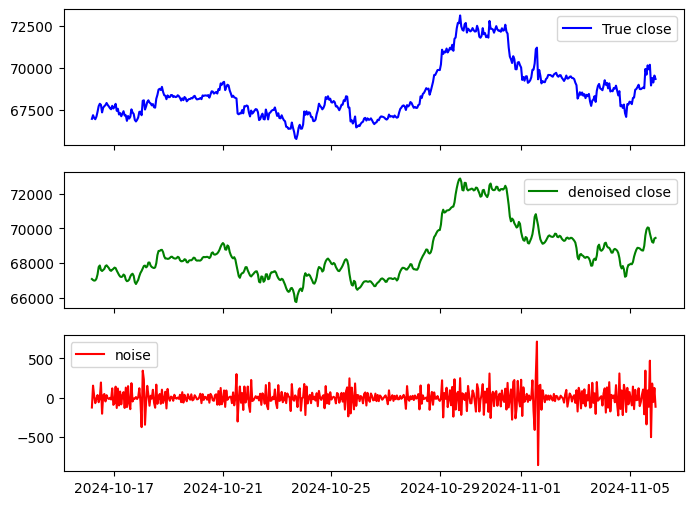

In [15]:
df[f'smoothed_data_{TRADE_PRICE}'] = wavelet_denoising(df[f'{TRADE_PRICE}'])
df['noise'] = df[f'{TRADE_PRICE}'] - df[f'smoothed_data_{TRADE_PRICE}']

import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8,6))
fig, axs = plt.subplots(3,1, figsize=(8,6), sharex=True)

axs[0].plot(df[f'{TRADE_PRICE}'].iloc[-500:], color = 'blue', label='True close')
axs[0].legend()

axs[1].plot(df[f'smoothed_data_{TRADE_PRICE}'].iloc[-500:], color = 'green', label='denoised close')
axs[1].legend()

axs[2].plot(df['noise'].iloc[-500:], color = 'red', label = 'noise')
axs[2].legend()


# MACD optimization

In [17]:
os.chdir(os.path.join('..', 'genetic'))
from classes import KalmanFilterEM, MACD_GA
os.chdir(os.path.join('..', 'macdxlstm'))


## Create sequence

In [36]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences, dtype=np.int32)

sequences = create_sequences(df[f'smoothed_data_{TRADE_PRICE}'].values, SEQ_LENGTH)
print(f'Created {len(sequences)} sequences of length {SEQ_LENGTH}.')

Created 3931 sequences of length 120.


In [ ]:
def optimize_macd(df, sequences, real_price = f'{TRADE_PRICE}', signal_price=f'smoothed_data_{TRADE_PRICE}'):

    

    # Initialize the optimizer
    optimizer = MACD_GA(df_train=df_train, real_price = real_price, signal_price=signal_price)
    
    # Run the genetic algorithm
    optimizer.run_ga()
    
    # Get the best parameters
    best_params = optimizer.get_best_parameters()
    return best_params[0:3]

In [44]:
best_macd_coefficients = np.zeros((len(sequences), 3))

for i, seq in enumerate(sequences):
    best_macd_coefficients[i] = optimize_macd(seq)

print(f'Best MACD coefficients shape: {best_macd_coefficients.shape}')
print(best_macd_coefficients)

only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Traceback (most recent call last):
  File "c:\Users\arvin\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygad\pygad.py", line 1708, in cal_pop_fitness
    fitness = self.fitness_func(self, sol, sol_idx)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arvin\Documents\Coding Project\V4\Algotrading_RL\src\genetic\classes.py", line 556, in fitness_function
    temp_data = self.macd(self.df_train.copy(), ema_fast, ema_slow, signal)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arvin\Documents\Coding Project\V4\Algotrading_RL\src\genetic\classes.py", line 530, in macd
    data['ema_fast'] = data[self.signal_price].ewm(span=fast, min_periods=1, adjust=False).mean()
                       ~~~~^^^^^^^^^^^^^^^^^^^
IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and in

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices